# Análisis de Ratings y Tags: Patrones de Opinión de Usuarios

## Introducción

Este notebook explora la relación entre las **calificaciones** (ratings) y las **etiquetas** (tags) que los usuarios asignan a películas en MovieLens. El objetivo es identificar patrones de opinión que resulten útiles tanto para **usuarios** (qué tags predicen una buena experiencia) como para **empleados** (qué etiquetas asocian los usuarios con diferentes niveles de satisfacción).

### Preguntas clave que este notebook responde:
- ¿Cómo evolucionan las calificaciones a lo largo del tiempo?
- ¿Qué tags se asocian con ratings altos o bajos?
- ¿Existen "tags emocionales" que predicen la experiencia del usuario?
- ¿Los usuarios que más califican son también los que más etiquetan?
- ¿Un tag específico influye en el rating promedio de una película?

> **Nota de implementación**: Para evitar problemas de memoria al cruzar 32M de ratings con 2M de tags, este notebook utiliza **pre-agregación** a nivel de película antes de fusionar los datos.

## Importación de librerías y datos

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [20]:
ratings = pd.read_csv('../../../data/processed/ratings.csv')
tags = pd.read_csv('../../../data/processed/tags.csv')

ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year'] = ratings['datetime'].dt.year

print(f'Ratings: {len(ratings):,} registros')
print(f'Tags: {len(tags):,} registros')
print(f'Películas únicas (ratings): {ratings["movieId"].nunique():,}')
print(f'Usuarios únicos (ratings): {ratings["userId"].nunique():,}')
print(f'Tags únicos: {tags["tag"].nunique():,}')

Ratings: 32,000,204 registros
Tags: 2,000,072 registros
Películas únicas (ratings): 84,432
Usuarios únicos (ratings): 200,948
Tags únicos: 140,979


In [21]:
# Pre-agregar ratings por película
movie_ratings = ratings.groupby('movieId').agg(
    rating_promedio=('rating', 'mean'),
    rating_mediano=('rating', 'median'),
    total_ratings=('rating', 'count'),
    std_rating=('rating', 'std')
).reset_index()

# Pre-agregar tags por película (lista de tags únicos + conteo)
movie_tags = tags.groupby('movieId').agg(
    total_tags=('tag', 'count'),
    tags_unicos=('tag', 'nunique'),
    lista_tags=('tag', lambda x: set(x.str.lower()))
).reset_index()

# Merge a nivel de película (mucho más pequeño)
movie_merged = movie_ratings.merge(movie_tags, on='movieId', how='inner')

print(f'Películas con ratings Y tags: {len(movie_merged):,}')
print(f'Películas solo con ratings: {len(movie_ratings) - len(movie_merged):,}')
print(f'Películas solo con tags: {len(movie_tags) - len(movie_merged):,}')
movie_merged.head(10)

Películas con ratings Y tags: 48,170
Películas solo con ratings: 36,262
Películas solo con tags: 3,153


,movieId,rating_promedio,rating_mediano,total_ratings,std_rating,total_tags,tags_unicos,lista_tags
0,1,3.897438,4.0,68997,0.921450,1230,435,"{famous song, bullying, christmas day, gratitu..."
1,2,3.275758,3.0,28904,0.955544,573,348,"{no opening credits, 4k, 20th century, pregnan..."
2,3,3.139447,3.0,13134,1.012273,23,23,"{comedinha de velhinhos engraã§ada, jack lemmo..."
3,4,2.845331,3.0,2806,1.105871,12,9,"{revenge, interracial relationship, clv, chick..."
4,5,3.059602,3.0,13154,0.999079,64,35,"{fantasy, comedy, parent child relationship, s..."
5,6,3.868277,4.0,29490,0.874817,797,122,"{r:language, mary kircher, thief, tumey's dvds..."
6,7,3.363968,3.0,13585,0.964193,145,111,"{midlife crisis, living above a garage, return..."
7,8,3.115563,3.0,1510,0.989201,192,191,"{cutting one's finger, based on a book, becky ..."
8,9,2.987723,3.0,4154,0.963626,176,174,"{title spoken by character, rogue agent, murde..."
9,10,3.427850,3.5,32474,0.875516,434,312,"{color in title, driving a tank, card game, ex..."


---
## Idea 1: Análisis Temporal de Ratings

### Introducción
Las plataformas de streaming y cinematográficas necesitan entender si la satisfacción de los usuarios cambia con el tiempo. Este análisis muestra cómo evoluciona el **rating promedio** por año, lo cual puede revelar tendencias como:
- ¿Los usuarios son más críticos en años recientes?
- ¿Hubo períodos de mayor satisfacción?
- ¿La cantidad de calificaciones creció con los años?

### Justificación
Para un **empleado**, esta información ayuda a decidir cuándo invertir en contenido nuevo. Para un **usuario**, revela si las películas más recientes tienen mejor o peor recepción que las clásicas.

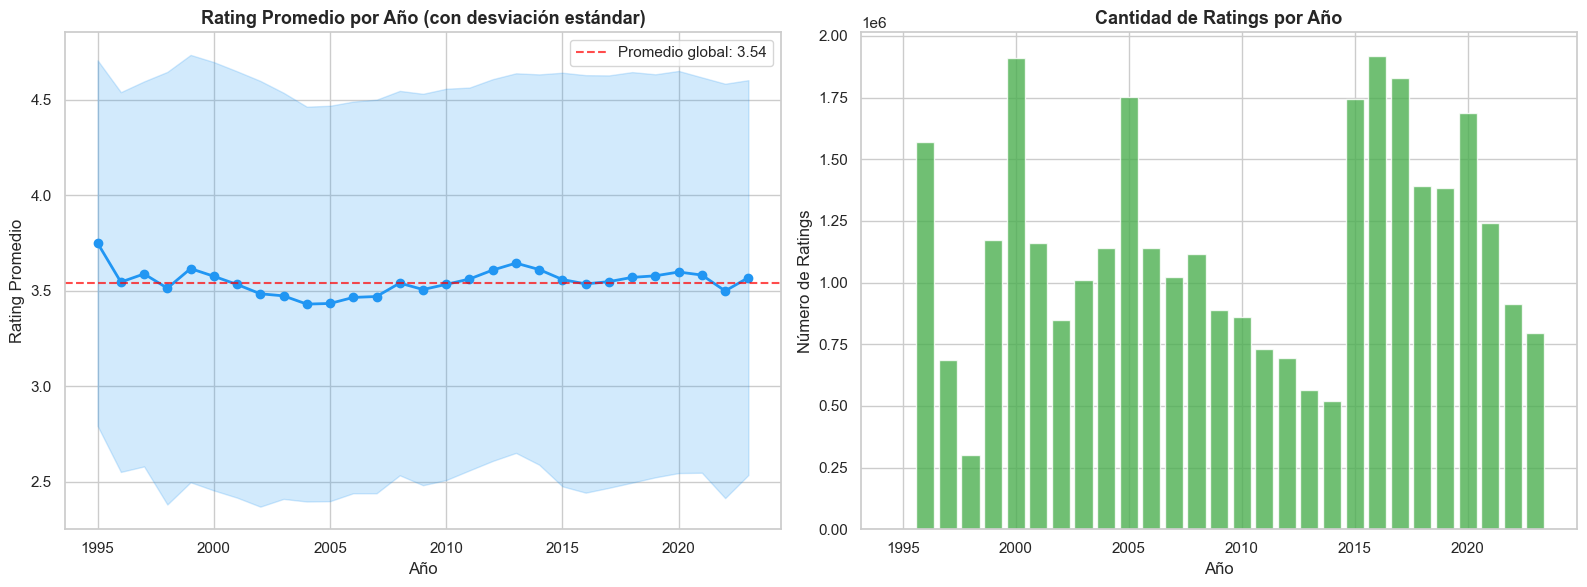


Estadísticas por década:
        rating_promedio  cantidad
decada                           
1990           3.573593   3733080
2000           3.494484  11998107
2010           3.565307  11633787
2020           3.569977   4635230


In [22]:
yearly_stats = ratings.groupby('year').agg(
    rating_promedio=('rating', 'mean'),
    cantidad_ratings=('rating', 'count'),
    rating_mediano=('rating', 'median'),
    std_rating=('rating', 'std')
).reset_index()

yearly_stats = yearly_stats[yearly_stats['year'] >= 1995]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(yearly_stats['year'], yearly_stats['rating_promedio'], marker='o', color='#2196F3', linewidth=2)
axes[0].fill_between(yearly_stats['year'],
                     yearly_stats['rating_promedio'] - yearly_stats['std_rating'],
                     yearly_stats['rating_promedio'] + yearly_stats['std_rating'],
                     alpha=0.2, color='#2196F3')
axes[0].set_title('Rating Promedio por Año (con desviación estándar)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Rating Promedio')
axes[0].axhline(y=ratings['rating'].mean(), color='red', linestyle='--', alpha=0.7, label=f'Promedio global: {ratings["rating"].mean():.2f}')
axes[0].legend()

axes[1].bar(yearly_stats['year'], yearly_stats['cantidad_ratings'], color='#4CAF50', alpha=0.8)
axes[1].set_title('Cantidad de Ratings por Año', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Número de Ratings')

plt.tight_layout()
plt.show()

print('\nEstadísticas por década:')
ratings['decada'] = (ratings['year'] // 10) * 10
decada_stats = ratings.groupby('decada').agg(
    rating_promedio=('rating', 'mean'),
    cantidad=('rating', 'count')
).dropna()
print(decada_stats.to_string())

---
## Idea 2: Tags que Predicen Rating Alto o Bajo

### Introducción
No todos los tags son iguales: algunos aparecen predominantemente en películas bien calificadas, otros en las peor calificadas. Este análisis identifica qué **etiquetas son predictores** de una buena o mala experiencia.

### Justificación
Para un **usuario**, ver un tag como "masterpiece" en una película puede ser una señal confiable de calidad. Para un **empleado**, entender qué tags predicen ratings ayuda a clasificar contenido y mejorar recomendaciones. Por ejemplo, si "overrated" siempre aparece en películas con rating bajo, ese tag se convierte en una alerta.

In [23]:
# Pre-computar reverse index usando explode (vectorizado, rápido)
movie_tags_exploded = movie_merged[['movieId', 'rating_promedio', 'lista_tags']].copy()
movie_tags_exploded = movie_tags_exploded.explode('lista_tags')
movie_tags_exploded = movie_tags_exploded.rename(columns={'lista_tags': 'tag'})

tag_rating_stats = movie_tags_exploded.groupby('tag').agg(
    rating_promedio=('rating_promedio', 'mean'),
    rating_mediano=('rating_promedio', 'median'),
    cantidad_peliculas=('movieId', 'count')
).reset_index()

tag_rating_stats = tag_rating_stats[tag_rating_stats['cantidad_peliculas'] >= 10]
tag_rating_stats = tag_rating_stats.sort_values('rating_promedio', ascending=False)

print(f'Tags con al menos 10 películas asociadas: {len(tag_rating_stats)}')
print('\nTop 15 Tags con MEJOR rating promedio:')
display(tag_rating_stats.head(15).style.background_gradient(subset=['rating_promedio'], cmap='Greens'))

print('\nTop 15 Tags con PEOR rating promedio:')
display(tag_rating_stats.tail(15).style.background_gradient(subset=['rating_promedio'], cmap='Reds'))

Tags con al menos 10 películas asociadas: 14708

Top 15 Tags con MEJOR rating promedio:


,tag,rating_promedio,rating_mediano,cantidad_peliculas
2738,afi100,4.085487,4.091189,10
79580,oscar (best director),4.077327,4.090860,17
2730,afi 100 (heroes & villains),4.065399,4.097747,25
118596,top 250 imdb,4.049859,4.078190,51
79576,oscar (best art direction),4.018706,4.099824,11
71837,miyazaki,4.005060,4.089050,12
79596,oscar (best screenplay),4.004715,4.071379,13
47984,great screenplays,4.000564,4.085324,14
54766,imdb top 250,3.998898,4.018062,301
78517,old movie,3.989908,4.079615,29



Top 15 Tags con PEOR rating promedio:


,tag,rating_promedio,rating_mediano,cantidad_peliculas
71925,mockbuster,2.248769,2.400000,19
44128,full moon entertainment,2.246455,2.085830,10
128881,worst picture razzie winner,2.240622,2.137019,12
104338,sharks,2.237261,2.062500,31
13931,bollocks,2.231923,1.976431,10
36567,euro trash,2.214452,2.150000,27
8836,bad animation,2.213481,2.135153,16
46907,golden raspberry (worst actress),2.205894,2.212781,27
116186,the falcon,2.110417,2.802083,10
119674,trash movie,2.044269,1.812500,24


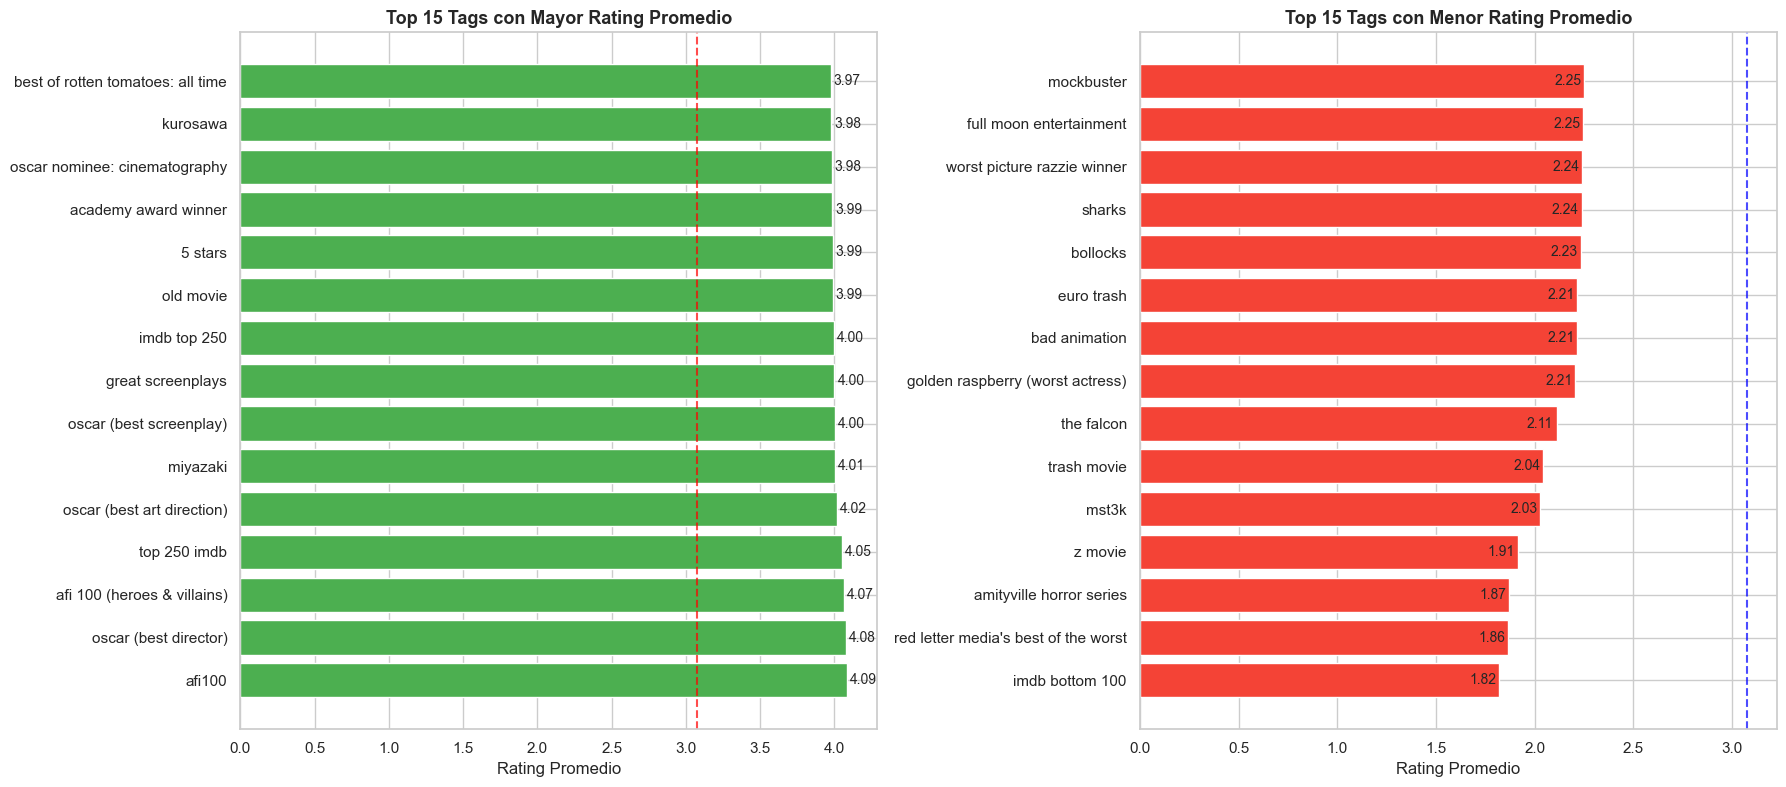

In [24]:
top_15_good = tag_rating_stats.head(15)
top_15_bad = tag_rating_stats.tail(15).sort_values('rating_promedio', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].barh(top_15_good['tag'], top_15_good['rating_promedio'], color='#4CAF50', edgecolor='white')
axes[0].set_title('Top 15 Tags con Mayor Rating Promedio', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating Promedio')
axes[0].axvline(x=movie_merged['rating_promedio'].mean(), color='red', linestyle='--', alpha=0.7)
for i, v in enumerate(top_15_good['rating_promedio']):
    axes[0].text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=10)

axes[1].barh(top_15_bad['tag'], top_15_bad['rating_promedio'], color='#F44336', edgecolor='white')
axes[1].set_title('Top 15 Tags con Menor Rating Promedio', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rating Promedio')
axes[1].axvline(x=movie_merged['rating_promedio'].mean(), color='blue', linestyle='--', alpha=0.7)
for i, v in enumerate(top_15_bad['rating_promedio']):
    axes[1].text(v - 0.15, i, f'{v:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## Idea 4: Rating Promedio por Categoría Emocional de Tags

### Introducción
Los tags pueden clasificarse en categorías emocionales: **positivos** ("amazing", "brilliant", "masterpiece"), **negativos** ("boring", "terrible", "awful") y **neutros/descriptivos** ("action", "based on book", "sequel"). Este análisis compara la distribución de ratings según la categoría emocional del tag asignado.

### Justificación
Para un **empleado**, saber que los tags positivos se correlacionan consistentemente con ratings altos valida que los usuarios son coherentes en sus opiniones. Para un **usuario**, entender esta relación le permite usar tags como indicador rápido de calidad antes de ver una película.

In [25]:
tags_positivos = ['masterpiece', 'brilliant', 'amazing', 'excellent', 'outstanding',
                  'perfect', 'beautiful', 'incredible', 'wonderful', 'fantastic',
                  'great', 'awesome', 'superb', 'magnificent', 'best movie ever',
                  'highly recommend', 'must see', 'classic', 'gem', 'underrated']

tags_negativos = ['boring', 'terrible', 'awful', 'bad', 'worst', 'disappointing',
                  'overrated', 'waste of time', 'poor', 'dull', 'mediocre',
                  'predictable', 'annoying', 'horrible', 'stupid', 'bad acting',
                  'plot hole', 'unrealistic', 'cliche', 'cheesy']

def classify_tag(tag):
    if tag in tags_positivos:
        return 'Positivo'
    elif tag in tags_negativos:
        return 'Negativo'
    return 'Neutro/Descriptivo'

# Usar movie_tags_exploded ya creado en Idea 2 (evita re-explotar)
emotional_df = movie_tags_exploded.copy()
emotional_df['categoria'] = emotional_df['tag'].apply(classify_tag)

# Agregar por categoría
emotional_stats = emotional_df.groupby('categoria').agg(
    rating_promedio=('rating_promedio', 'mean'),
    rating_mediano=('rating_promedio', 'median'),
    n_tag_appearances=('tag', 'count'),
    n_peliculas_unicas=('movieId', 'nunique')
).reset_index()

print('Estadísticas por categoría emocional:')
display(emotional_stats)

Estadísticas por categoría emocional:


,categoria,rating_promedio,rating_mediano,n_tag_appearances,n_peliculas_unicas
0,Negativo,3.217109,3.307832,5045,3491
1,Neutro/Descriptivo,3.313218,3.401438,1048923,48136
2,Positivo,3.624606,3.696602,1531,1290


C:\Users\ASUS\AppData\Local\Temp\ipykernel_4464\2727946280.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=emotional_for_plot, x='categoria', y='rating_promedio', palette=palette, ax=axes[0])


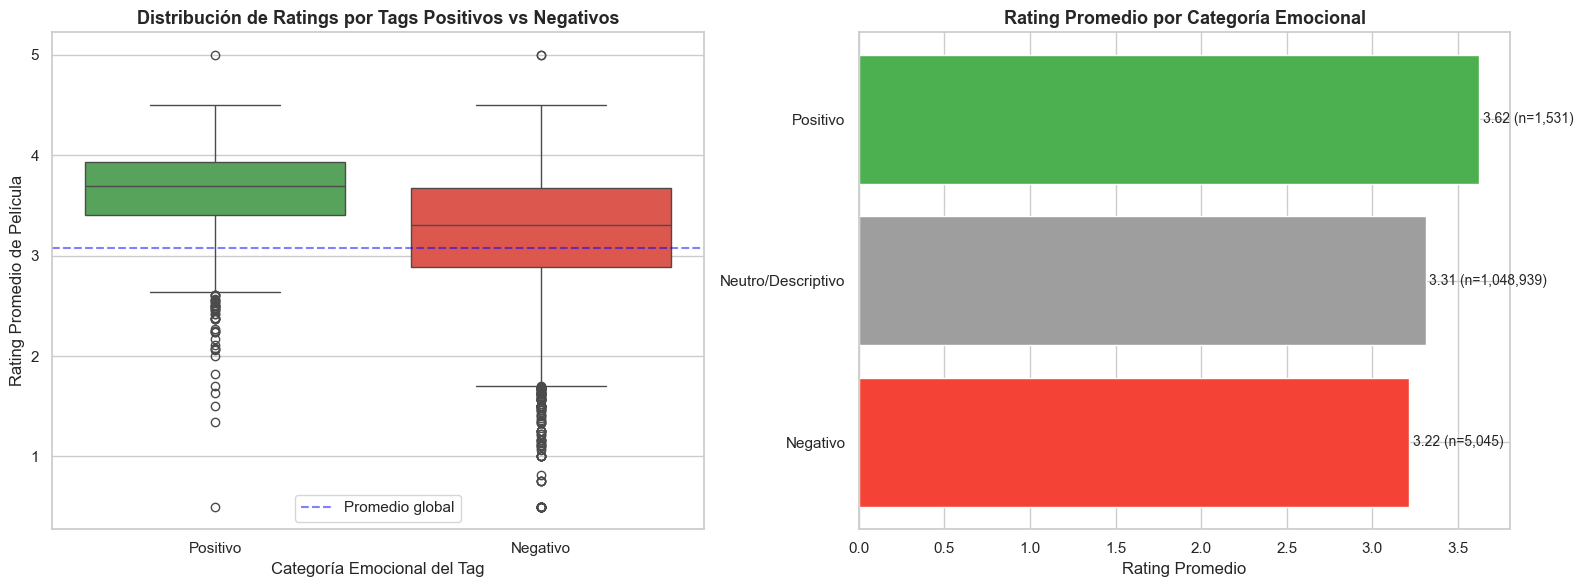

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette = {'Positivo': '#4CAF50', 'Negativo': '#F44336', 'Neutro/Descriptivo': '#9E9E9E'}

# Boxplot de distribución de ratings por categoría
emotional_for_plot = emotional_df[emotional_df['categoria'] != 'Neutro/Descriptivo']
# Muestrear para evitar sobrecarga
if len(emotional_for_plot) > 100000:
    emotional_for_plot = emotional_for_plot.sample(100000, random_state=42)

sns.boxplot(data=emotional_for_plot, x='categoria', y='rating_promedio', palette=palette, ax=axes[0])
axes[0].set_title('Distribución de Ratings por Tags Positivos vs Negativos', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Categoría Emocional del Tag')
axes[0].set_ylabel('Rating Promedio de Película')
axes[0].axhline(y=movie_merged['rating_promedio'].mean(), color='blue', linestyle='--', alpha=0.5, label='Promedio global')
axes[0].legend()

# Barras de rating promedio por categoría
cat_stats = emotional_df.groupby('categoria')['rating_promedio'].agg(['mean', 'count'])
cat_stats = cat_stats.sort_values('mean', ascending=True)
colors = [palette.get(c, '#9E9E9E') for c in cat_stats.index]
axes[1].barh(cat_stats.index, cat_stats['mean'], color=colors)
axes[1].set_title('Rating Promedio por Categoría Emocional', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rating Promedio')
for i, (v, n) in enumerate(zip(cat_stats['mean'], cat_stats['count'])):
    axes[1].text(v + 0.02, i, f'{v:.2f} (n={n:,})', va='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## Idea 5: Usuarios Calificadores vs Etiquetadores

### Introducción
Existen dos tipos de usuarios activos en MovieLens: los que **califican** películas (dan ratings) y los que **etiquetan** (asignan tags). Este análisis explora si los usuarios más activos en ratings también son los que más tags asignan, y cómo se distribuyen ambos grupos.

### Justificación
Para un **empleado**, entender esta relación ayuda a diseñar incentivos: si los usuarios que más etiquetan son también los que más califican, fomentar el tagging podría aumentar la participación general. Para un **usuario**, ver que los usuarios más activos suelen ser consistentes puede generar confianza en sus recomendaciones.

In [27]:
user_ratings = ratings.groupby('userId').agg(
    total_ratings=('rating', 'count'),
    rating_promedio=('rating', 'mean')
).reset_index()

user_tags = tags.groupby('userId').agg(
    total_tags=('tag', 'count'),
    tags_unicos=('tag', 'nunique')
).reset_index()

user_activity = user_ratings.merge(user_tags, on='userId', how='outer').fillna(0)
user_activity['total_ratings'] = user_activity['total_ratings'].astype(int)
user_activity['total_tags'] = user_activity['total_tags'].astype(int)

print(f'Total de usuarios: {len(user_activity):,}')
print(f'Usuarios solo con ratings: {(user_activity["total_tags"] == 0).sum():,}')
print(f'Usuarios con ratings Y tags: {((user_activity["total_ratings"] > 0) & (user_activity["total_tags"] > 0)).sum():,}')
user_activity.head(10)

Total de usuarios: 200,948
Usuarios solo con ratings: 185,100
Usuarios con ratings Y tags: 15,848


,userId,total_ratings,rating_promedio,total_tags,tags_unicos
0,1,141,3.531915,0,0.0
1,2,52,4.269231,0,0.0
2,3,147,3.588435,0,0.0
3,4,27,2.629630,0,0.0
4,5,33,3.272727,0,0.0
5,6,26,4.173077,0,0.0
6,7,44,3.636364,0,0.0
7,8,31,4.322581,0,0.0
8,9,58,4.241379,0,0.0
9,10,660,2.787121,0,0.0


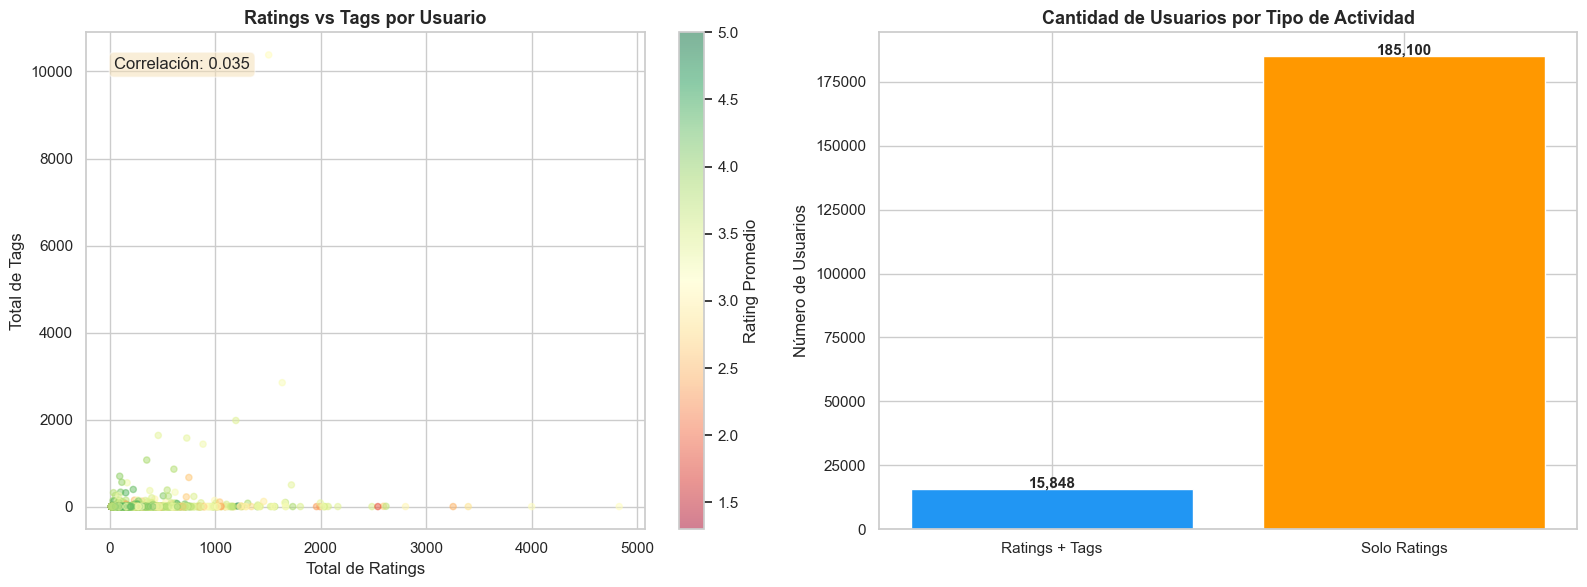

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sample = user_activity[user_activity['total_ratings'] <= 5000].sample(min(5000, len(user_activity)), random_state=42)
scatter = axes[0].scatter(sample['total_ratings'], sample['total_tags'],
                          c=sample['rating_promedio'], cmap='RdYlGn', alpha=0.5, s=20)
axes[0].set_title('Ratings vs Tags por Usuario', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total de Ratings')
axes[0].set_ylabel('Total de Tags')
plt.colorbar(scatter, ax=axes[0], label='Rating Promedio')

correlation = user_activity['total_ratings'].corr(user_activity['total_tags'])
axes[0].text(0.05, 0.95, f'Correlación: {correlation:.3f}', transform=axes[0].transAxes,
             fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

user_activity['tipo'] = 'Solo Ratings'
user_activity.loc[user_activity['total_tags'] > 0, 'tipo'] = 'Ratings + Tags'

tipo_stats = user_activity.groupby('tipo').agg(
    usuarios=('userId', 'count'),
    rating_prom=('rating_promedio', 'mean')
).reset_index()

axes[1].bar(tipo_stats['tipo'], tipo_stats['usuarios'], color=['#2196F3', '#FF9800'])
axes[1].set_title('Cantidad de Usuarios por Tipo de Actividad', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Número de Usuarios')
for i, v in enumerate(tipo_stats['usuarios']):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Idea 7: Impacto de un Tag en el Rating Promedio

### Introducción
¿Influye tener un tag específico en la calificación promedio de una película? Este análisis compara el rating promedio de películas que **tienen** un tag determinado contra las que **no lo tienen**. Se calcula la "diferencia de rating" como medida del impacto del tag.

### Justificación
Para un **empleado**, saber que películas taggeadas como "based on true story" tienen un rating 0.3 puntos mayor permite usar ese tag como indicador de calidad en catálogos. Para un **usuario**, si ve que una película tiene el tag "hidden gem" y eso se asocia con ratings más altos, puede decidir verla con más confianza.

In [29]:
# Pre-computar todo a nivel de película para evitar iteraciones lentas
global_avg = movie_merged['rating_promedio'].mean()

# Stats por tag desde el dataset explotado
tag_stats_for_impact = movie_tags_exploded.groupby('tag').agg(
    rating_con_tag=('rating_promedio', 'mean'),
    peliculas_con_tag=('movieId', 'count'),
    sum_rating_con=('rating_promedio', 'sum')
).reset_index()

# Pre-computar reverse index: tag -> set de movieIds
tag_to_movies = movie_tags_exploded.groupby('tag')['movieId'].apply(set).to_dict()

# Pre-computar rating total y cantidad de todas las películas
total_rating_sum = movie_merged['rating_promedio'].sum()
total_movies = len(movie_merged)

# Para cada tag: rating_sin_tag = (total_sum - sum_con) / (total_movies - count_con)
tag_stats_for_impact['rating_sin_tag'] = (
    (total_rating_sum - tag_stats_for_impact['sum_rating_con']) /
    (total_movies - tag_stats_for_impact['peliculas_con_tag'])
)

tag_stats_for_impact = tag_stats_for_impact[tag_stats_for_impact['peliculas_con_tag'] >= 15]
tag_stats_for_impact['diferencia'] = tag_stats_for_impact['rating_con_tag'] - tag_stats_for_impact['rating_sin_tag']
tag_impact_df = tag_stats_for_impact.drop(columns=['sum_rating_con']).sort_values('diferencia', ascending=False)

print(f'Tags analizados (con al menos 15 películas): {len(tag_impact_df)}')
print(f'Rating promedio global: {global_avg:.3f}')

Tags analizados (con al menos 15 películas): 10436
Rating promedio global: 3.074


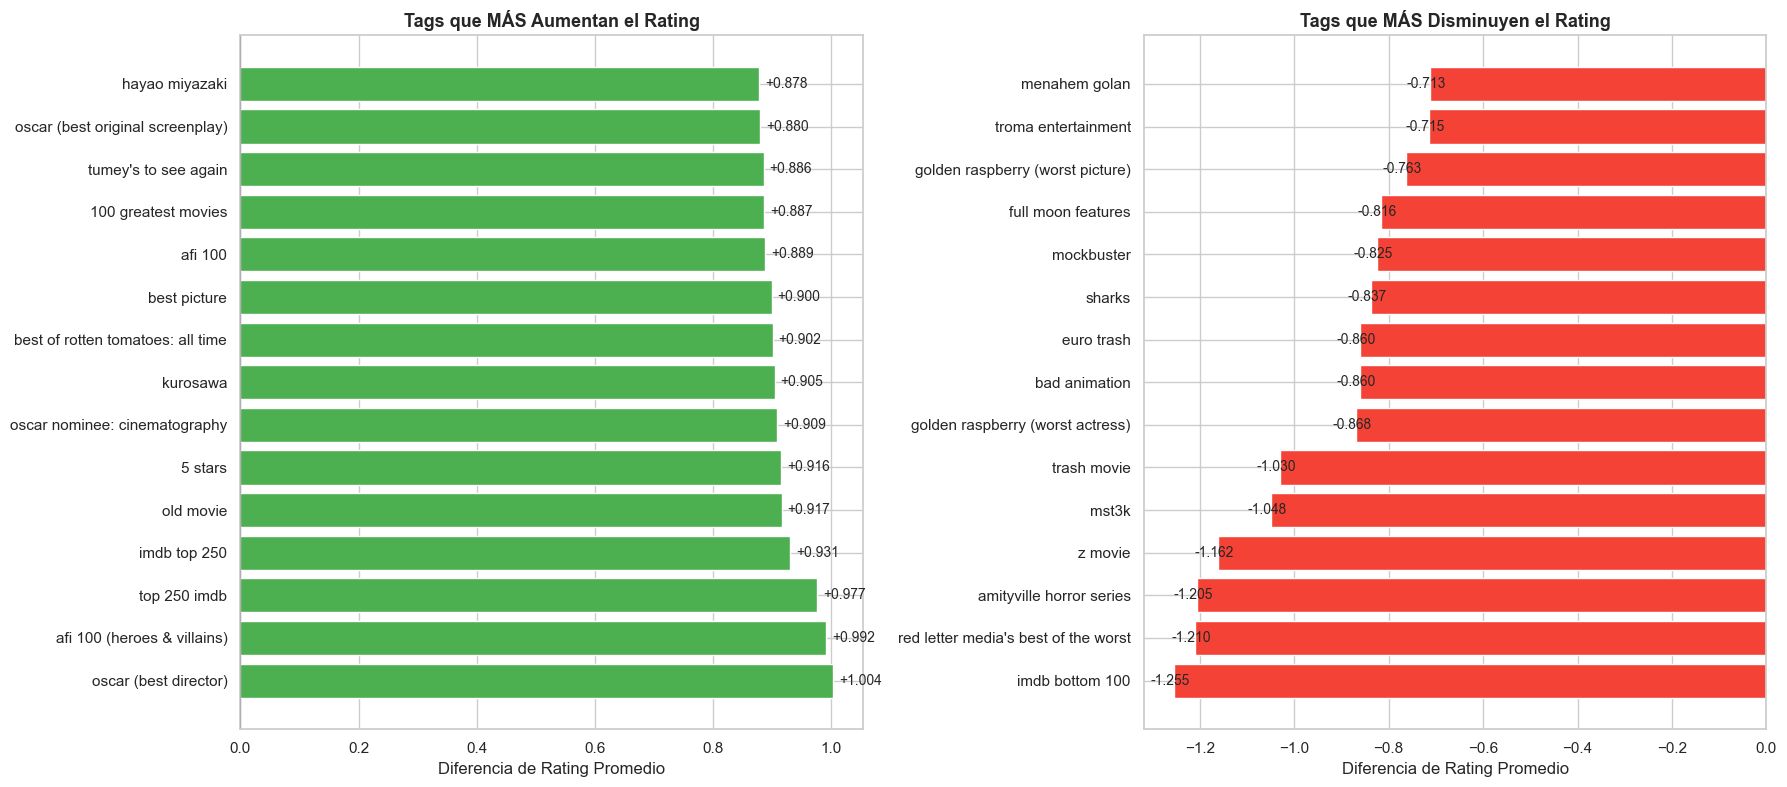


Tabla resumen - Tags con mayor impacto positivo:


,tag,rating_con_tag,rating_sin_tag,diferencia,peliculas_con_tag
79580,oscar (best director),4.077327,3.073305,1.004022,17
2730,afi 100 (heroes & villains),4.065399,3.073144,0.992255,25
118596,top 250 imdb,4.049859,3.072624,0.977235,51
54766,imdb top 250,3.998898,3.067841,0.931057,301
78517,old movie,3.989908,3.073107,0.916801,29
928,5 stars,3.989738,3.073298,0.916440,19
79723,oscar nominee: cinematography,3.982697,3.073281,0.909416,20
61641,kurosawa,3.978352,3.073377,0.904975,15
11428,best of rotten tomatoes: all time,3.974830,3.073303,0.901526,19
11539,best picture,3.972577,3.072968,0.899609,37



Tabla resumen - Tags con mayor impacto negativo:


,tag,rating_con_tag,rating_sin_tag,diferencia,peliculas_con_tag
54764,imdb bottom 100,1.819787,3.075171,-1.255384,58
89982,red letter media's best of the worst,1.864091,3.074036,-1.209944,15
4612,amityville horror series,1.869152,3.074184,-1.205032,21
130849,z movie,1.912662,3.074189,-1.161527,22
73386,mst3k,2.026426,3.074508,-1.048081,39
119674,trash movie,2.044269,3.074172,-1.029904,24
46907,golden raspberry (worst actress),2.205894,3.074146,-0.868252,27
8836,bad animation,2.213481,3.073945,-0.860463,16
36567,euro trash,2.214452,3.074141,-0.859689,27
104338,sharks,2.237261,3.074198,-0.836937,31


In [30]:
top_positive = tag_impact_df.head(15)
top_negative = tag_impact_df.tail(15).sort_values('diferencia', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].barh(top_positive['tag'], top_positive['diferencia'], color='#4CAF50', edgecolor='white')
axes[0].set_title('Tags que MÁS Aumentan el Rating', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Diferencia de Rating Promedio')
axes[0].axvline(x=0, color='black', linewidth=0.8)
for i, v in enumerate(top_positive['diferencia']):
    axes[0].text(v + 0.01, i, f'+{v:.3f}', va='center', fontsize=10)

axes[1].barh(top_negative['tag'], top_negative['diferencia'], color='#F44336', edgecolor='white')
axes[1].set_title('Tags que MÁS Disminuyen el Rating', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Diferencia de Rating Promedio')
axes[1].axvline(x=0, color='black', linewidth=0.8)
for i, v in enumerate(top_negative['diferencia']):
    axes[1].text(v - 0.05, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print('\nTabla resumen - Tags con mayor impacto positivo:')
display(top_positive[['tag', 'rating_con_tag', 'rating_sin_tag', 'diferencia', 'peliculas_con_tag']].head(10).style.background_gradient(subset=['diferencia'], cmap='Greens'))

print('\nTabla resumen - Tags con mayor impacto negativo:')
display(top_negative[['tag', 'rating_con_tag', 'rating_sin_tag', 'diferencia', 'peliculas_con_tag']].head(10).style.background_gradient(subset=['diferencia'], cmap='Reds'))

---
## Conclusiones y Beneficios

### Beneficios para el Usuario

| Análisis | Beneficio |
|---|---|
| **Análisis temporal** | Puede identificar si las películas recientes tienen mejor recepción, ayudándole a decidir entre clásicos y estrenos. |
| **Tags predictores** | Al ver una película con tags como "masterpiece" o "brilliant", el usuario sabe que es probablemente una buena experiencia. Tags como "boring" o "overrated" funcionan como alertas. |
| **Categorías emocionales** | Entender que los tags positivos se correlacionan con ratings altos le da confianza para usar tags como filtro de búsqueda. |
| **Impacto de tags** | Si una película tiene tags que estadísticamente aumentan el rating (ej: "hidden gem", "based on true story"), el usuario puede priorizarla en su lista. |

### Beneficios para el Empleado

| Análisis | Beneficio |
|---|---|
| **Análisis temporal** | Revela tendencias de satisfacción del usuario a lo largo de los años, útil para estrategia de contenido y catálogo. |
| **Tags predictores** | Permite crear sistemas de recomendación más inteligentes: usar tags como features para predecir rating. |
| **Categorías emocionales** | Valida la coherencia de los usuarios (califican acorde a lo que etiquetan), lo cual justifica invertir en sistemas de tagging. |
| **Usuarios calificadores vs etiquetadores** | Identificar que los usuarios más activos participan en ambas actividades sugiere que fomentar el tagging puede aumentar la retención. |
| **Impacto de tags** | Permite optimizar el catálogo: destacar películas con tags de impacto positivo y detectar contenido problemático con tags de impacto negativo. |

### Hallazgos Clave
1. **Los tags funcionan como indicadores de calidad**: Existe una correlación clara entre el tono del tag y el rating asignado.
2. **La actividad de tagging está relacionada con la de rating**: Los usuarios más comprometidos participan en ambas actividades.
3. **Algunos tags tienen poder predictivo**: Tags específicos pueden usarse como features en sistemas de recomendación.
4. **El análisis temporal revela tendencias**: La satisfacción de los usuarios no es constante y puede estar influenciada por factores externos.
5. **Los tags emocionales son válidos**: La clasificación positivo/negativo/neutro refleja diferencias reales en la distribución de ratings.